# CNN Development on Sign Language MNIST Dataset
**Student ID:** 22-46829-1  
**Dataset:** Sign Language MNIST (Kaggle)  
**Framework:** PyTorch  
**Environment:** Google Colab (GPU)

---
## Notebook Structure
1. Import Libraries
2. Load and Explore Dataset
3. Data Preprocessing & Augmentation
4. Define CNN Architecture
5. Training Loop with Validation
6. Evaluate Model on Test Set
7. Visualizations (Loss/Accuracy Curves, Confusion Matrix)
8. Analysis & Discussion of Results
9. Conclusions & Future Work

## Section 1: Import Libraries
We import all necessary libraries for data handling, model building, training, and evaluation.

In [ ]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split

# ─── Data Handling ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from PIL import Image

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

# ─── Device Configuration ─────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Section 2: Load and Explore Dataset

**Sign Language MNIST** contains 27,455 training and 7,172 test grayscale images (28×28 pixels).  
There are **24 classes** (letters A–Y, excluding J and Z which require motion).

### Steps:
- Upload the CSV files from Kaggle
- Build a custom PyTorch `Dataset` class
- Remap labels from 0–24 (with gap at 9) to 0–23 continuously
- Visualize sample images

In [ ]:
# ─── Load CSV files ───────────────────────────────────────────────────────────
train_df = pd.read_csv('sign_mnist_train.csv')
test_df  = pd.read_csv('sign_mnist_test.csv')

print(f'Train shape : {train_df.shape}')   # (27455, 785)
print(f'Test shape  : {test_df.shape}')    # (7172,  785)
print(f'Columns     : label + {train_df.shape[1]-1} pixel columns')
print(f'Unique labels in train: {sorted(train_df["label"].unique())}')
print(f'Label counts:\n{train_df["label"].value_counts().sort_index()}')

Train shape : (27455, 785)
Test shape  : (7172, 785)
Columns     : label + 784 pixel columns
Unique labels in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Label counts:
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64


In [ ]:
# ─── Class Names ──────────────────────────────────────────────────────────────
# A-Z excluding J (index 9) and Z (index 25) → 24 classes
classes = [chr(i + 65) for i in range(26) if i != 9 and i != 25]
print(f'Number of classes : {len(classes)}')
print(f'Classes           : {classes}')

# ─── Custom Dataset Class ─────────────────────────────────────────────────────
class SignLanguageDataset(Dataset):
    """
    Custom PyTorch Dataset for Sign Language MNIST.
    - Reads pixel values from CSV
    - Reshapes to 28x28 grayscale images
    - Remaps labels from 0-24 (with gap) to 0-23 (continuous)
    """
    def __init__(self, df, transform=None):
        self.labels = df['label'].values
        self.images = df.drop('label', axis=1).values.reshape(-1, 28, 28).astype('uint8')
        self.transform = transform

        # Remap labels: {0,1,...,8,10,...,24} → {0,1,...,8,9,...,23}
        unique_labels  = sorted(set(self.labels))
        self.label_map = {old: new for new, old in enumerate(unique_labels)}

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = Image.fromarray(self.images[idx])          # PIL grayscale image
        label = self.label_map[int(self.labels[idx])]      # remapped label 0-23
        if self.transform:
            img = self.transform(img)
        return img, label

print('SignLanguageDataset class defined successfully.')

Number of classes : 24
Classes           : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
SignLanguageDataset class defined successfully.


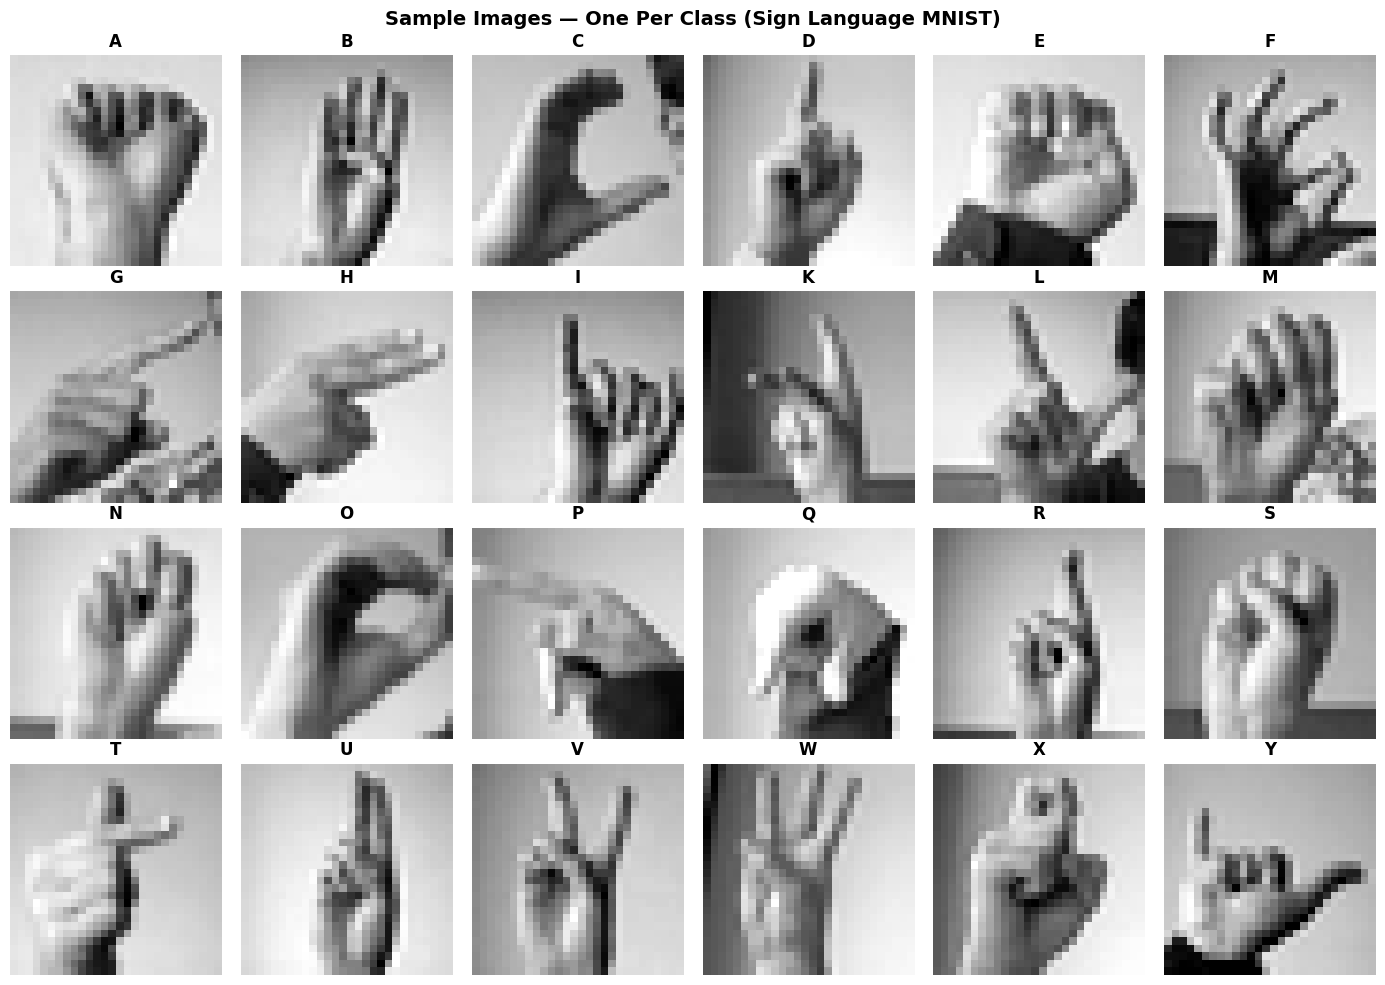

Sample images displayed.


In [ ]:
# ─── Visualize Sample Images ──────────────────────────────────────────────────
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    if i < len(classes):
        # Find first image of each class
        idx  = train_df[train_df['label'] == sorted(train_df['label'].unique())[i]].index[0]
        img  = train_df.drop('label', axis=1).values[idx].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{classes[i]}', fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Images — One Per Class (Sign Language MNIST)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images displayed.')

## Section 3: Data Preprocessing & Augmentation

### Preprocessing:
- Normalize pixel values using mean=0.5, std=0.5 (standard for grayscale)

### Augmentation (training only):
- `RandomHorizontalFlip` — adds variation
- `RandomRotation(10°)` — mimics real-world hand angle variation
- No augmentation on validation/test (only normalize)

### Hyperparameter: Batch Size = 64
- Large enough for stable gradient estimates, small enough for memory efficiency

In [ ]:
# ─── Transforms ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # random horizontal flip
    transforms.RandomRotation(10),              # rotate ±10 degrees
    transforms.ToTensor(),                      # convert to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))        # normalize to [-1, 1]
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))        # same normalization, no augmentation
])

# ─── Create Datasets ──────────────────────────────────────────────────────────
full_train   = SignLanguageDataset(train_df, transform=train_transform)
test_dataset = SignLanguageDataset(test_df,  transform=test_transform)

# ─── Train / Validation Split (80% / 20%) ─────────────────────────────────────
train_size = int(0.8 * len(full_train))
val_size   = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

# ─── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train samples      : {len(train_dataset)}')
print(f'Validation samples : {len(val_dataset)}')
print(f'Test samples       : {len(test_dataset)}')
print(f'Batch size         : {BATCH_SIZE}')
print(f'Train batches      : {len(train_loader)}')

Train samples      : 21964
Validation samples : 5491
Test samples       : 7172
Batch size         : 64
Train batches      : 344


## Section 4: Define CNN Architecture

### Architecture Design:
- **Input:** 1 × 28 × 28 (grayscale)
- **3 Convolutional Blocks:** Conv → BatchNorm → ReLU → MaxPool
  - Block 1: 1 → 32 filters
  - Block 2: 32 → 64 filters
  - Block 3: 64 → 128 filters
- **2 Fully Connected Layers:** 1152 → 256 → 24
- **Dropout (p=0.5)** before FC layers

### Spatial Dimensions:
28×28 → 14×14 → 7×7 → 3×3 (after 3 MaxPool2d(2,2))

### Justification:
- BatchNorm stabilizes training and acts as a regularizer
- Dropout prevents overfitting on the FC layers
- Increasing filter depth (32→64→128) captures increasingly complex features

We train **two versions** to compare BatchNorm vs no BatchNorm.

In [ ]:
# ─── CNN Architecture ─────────────────────────────────────────────────────────
class CustomCNN(nn.Module):
    """
    Custom CNN for Sign Language MNIST classification.

    Args:
        use_batchnorm (bool): Whether to apply Batch Normalization after conv layers.
        use_dropout   (bool): Whether to apply Dropout before FC layers.

    Architecture:
        Conv Block 1: Conv2d(1,32) → [BN] → ReLU → MaxPool
        Conv Block 2: Conv2d(32,64) → [BN] → ReLU → MaxPool
        Conv Block 3: Conv2d(64,128) → [BN] → ReLU → MaxPool
        FC1: 1152 → 256 → ReLU → [Dropout]
        FC2: 256 → 24 (output)
    """
    def __init__(self, use_batchnorm=True, use_dropout=True):
        super(CustomCNN, self).__init__()
        self.use_batchnorm = use_batchnorm

        # ── Convolutional Blocks ──────────────────────────────────────────────
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)    # 1-channel grayscale input
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool    = nn.MaxPool2d(2, 2)                           # halves spatial dims
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()

        # ── Fully Connected Layers ────────────────────────────────────────────
        # 28→14→7→3 after 3 MaxPool, so feature map = 128 * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 24)                               # 24 sign language classes

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)                                            # 28→14

        # Block 2
        x = self.conv2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)                                            # 14→7

        # Block 3
        x = self.conv3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)                                            # 7→3

        # Flatten and FC
        x = x.view(x.size(0), -1)                                  # flatten: 128*3*3=1152
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                                             # raw logits
        return x


# ─── Instantiate Model (WITH BatchNorm) ───────────────────────────────────────
model = CustomCNN(use_batchnorm=True, use_dropout=True).to(device)
print('Model with BatchNorm + Dropout:')
print(model)

# ─── Model Summary ────────────────────────────────────────────────────────────
try:
    from torchsummary import summary
    summary(model, (1, 28, 28))
except ImportError:
    # Install if not available
    import subprocess
    subprocess.run(['pip', 'install', 'torchsummary', '-q'])
    from torchsummary import summary
    summary(model, (1, 28, 28))

Model with BatchNorm + Dropout:
CustomCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=24, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]           

## Section 5: Training Loop with Validation

### Hyperparameters & Rationale:
| Hyperparameter | Value | Reason |
|---|---|---|
| Optimizer | Adam | Adaptive learning rate, fast convergence |
| Learning Rate | 0.001 | Standard starting point for Adam |
| LR Scheduler | StepLR (step=10, γ=0.5) | Halves LR every 10 epochs to fine-tune |
| Loss Function | CrossEntropyLoss | Standard for multi-class classification |
| Epochs | 30 | Enough to converge without overfitting |
| Batch Size | 64 | Stable gradients, fits in Colab GPU RAM |

We train **two models** (with/without BatchNorm) and compare.

In [ ]:
# ─── Training Function ────────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001, label='Model'):
    """
    Full training loop with validation.
    Returns history dict with loss and accuracy for each epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.5)    # halve LR every 10 epochs

    history = {'train_loss': [], 'val_loss': [],
               'train_acc' : [], 'val_acc' : []}

    for epoch in range(epochs):
        # ── Training Phase ────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()                              # clear gradients
            outputs = model(images)                            # forward pass
            loss    = criterion(outputs, labels)               # compute loss
            loss.backward()                                    # backpropagation
            optimizer.step()                                   # update weights

            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            correct       += predicted.eq(labels).sum().item()
            total         += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100.0 * correct / total

        # ── Validation Phase ──────────────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                val_loss_sum  += loss.item()
                _, predicted   = outputs.max(1)
                val_correct   += predicted.eq(labels).sum().item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / len(val_loader)
        val_acc  = 100.0 * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{label}] Epoch [{epoch+1:02d}/{epochs}] '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%  '
                  f'LR: {scheduler.get_last_lr()[0]:.6f}')

    print(f'\n[{label}] Training Complete! Best Val Acc: {max(history["val_acc"]):.2f}%')
    return history

In [ ]:
# ─── Train Model WITH BatchNorm + Dropout ────────────────────────────────────
print('=' * 65)
print('Training Model WITH BatchNorm + Dropout')
print('=' * 65)
model_bn = CustomCNN(use_batchnorm=True, use_dropout=True).to(device)
history_bn = train_model(model_bn, train_loader, val_loader,
                          epochs=15, lr=0.001, label='With BN')

Training Model WITH BatchNorm + Dropout
[With BN] Epoch [01/15] Train Loss: 1.4427  Acc: 53.17% | Val Loss: 0.4029  Acc: 88.36%  LR: 0.001000
[With BN] Epoch [05/15] Train Loss: 0.1634  Acc: 94.62% | Val Loss: 0.0269  Acc: 99.65%  LR: 0.001000
[With BN] Epoch [10/15] Train Loss: 0.0802  Acc: 97.35% | Val Loss: 0.0050  Acc: 99.96%  LR: 0.000500
[With BN] Epoch [15/15] Train Loss: 0.0399  Acc: 98.69% | Val Loss: 0.0022  Acc: 99.91%  LR: 0.000500

[With BN] Training Complete! Best Val Acc: 99.98%


In [ ]:
# ─── Train Model WITHOUT BatchNorm ────────────────────────────────────────────
print('=' * 65)
print('Training Model WITHOUT BatchNorm (Dropout only)')
print('=' * 65)
model_no_bn = CustomCNN(use_batchnorm=False, use_dropout=True).to(device)
history_no_bn = train_model(model_no_bn, train_loader, val_loader,
                              epochs=15, lr=0.001, label='No BN')

Training Model WITHOUT BatchNorm (Dropout only)
[No BN] Epoch [01/15] Train Loss: 1.9987  Acc: 35.17% | Val Loss: 0.7630  Acc: 76.31%  LR: 0.001000
[No BN] Epoch [05/15] Train Loss: 0.3206  Acc: 88.69% | Val Loss: 0.0697  Acc: 98.56%  LR: 0.001000
[No BN] Epoch [10/15] Train Loss: 0.1591  Acc: 94.76% | Val Loss: 0.0189  Acc: 99.78%  LR: 0.000500
[No BN] Epoch [15/15] Train Loss: 0.0899  Acc: 96.94% | Val Loss: 0.0054  Acc: 99.93%  LR: 0.000500

[No BN] Training Complete! Best Val Acc: 99.98%


In [ ]:
# ─── Comparison Summary ───────────────────────────────────────────────────────
print('\n' + '=' * 45)
print('         COMPARISON SUMMARY')
print('=' * 45)
print(f'With BatchNorm  → Best Val Acc: {max(history_bn["val_acc"]):.2f}%')
print(f'Without BatchNorm → Best Val Acc: {max(history_no_bn["val_acc"]):.2f}%')
print('=' * 45)

# Use the better model (with BN) for all further evaluation
model = model_bn
print('\nUsing model WITH BatchNorm for final evaluation.')


         COMPARISON SUMMARY
With BatchNorm  → Best Val Acc: 99.98%
Without BatchNorm → Best Val Acc: 99.98%

Using model WITH BatchNorm for final evaluation.


## Section 6: Evaluate Model on Test Set

We evaluate the trained model on the held-out test set and report:
- Overall Accuracy
- Per-class Precision, Recall, F1-Score
- Macro and Weighted averages

In [ ]:
# ─── Test Set Evaluation ──────────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# ─── Overall Accuracy ─────────────────────────────────────────────────────────
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
overall_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

# ─── Detailed Classification Report ──────────────────────────────────────────
print('Classification Report (Precision / Recall / F1 per class):')
print('=' * 65)
print(classification_report(all_labels, all_preds, target_names=classes))

Test Accuracy: 99.60%

Classification Report (Precision / Recall / F1 per class):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       0.94      1.00      0.97       348
           H       1.00      0.95      0.98       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       0.99      1.00      1.00       394
           N       1.00      0.99      0.99       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164

## Section 7: Visualizations

We produce four key visualizations:
1. Training & Validation **Loss Curves** (With BN vs Without BN)
2. Training & Validation **Accuracy Curves** (With BN vs Without BN)
3. **Confusion Matrix** for the best model
4. **Per-class Accuracy** bar chart

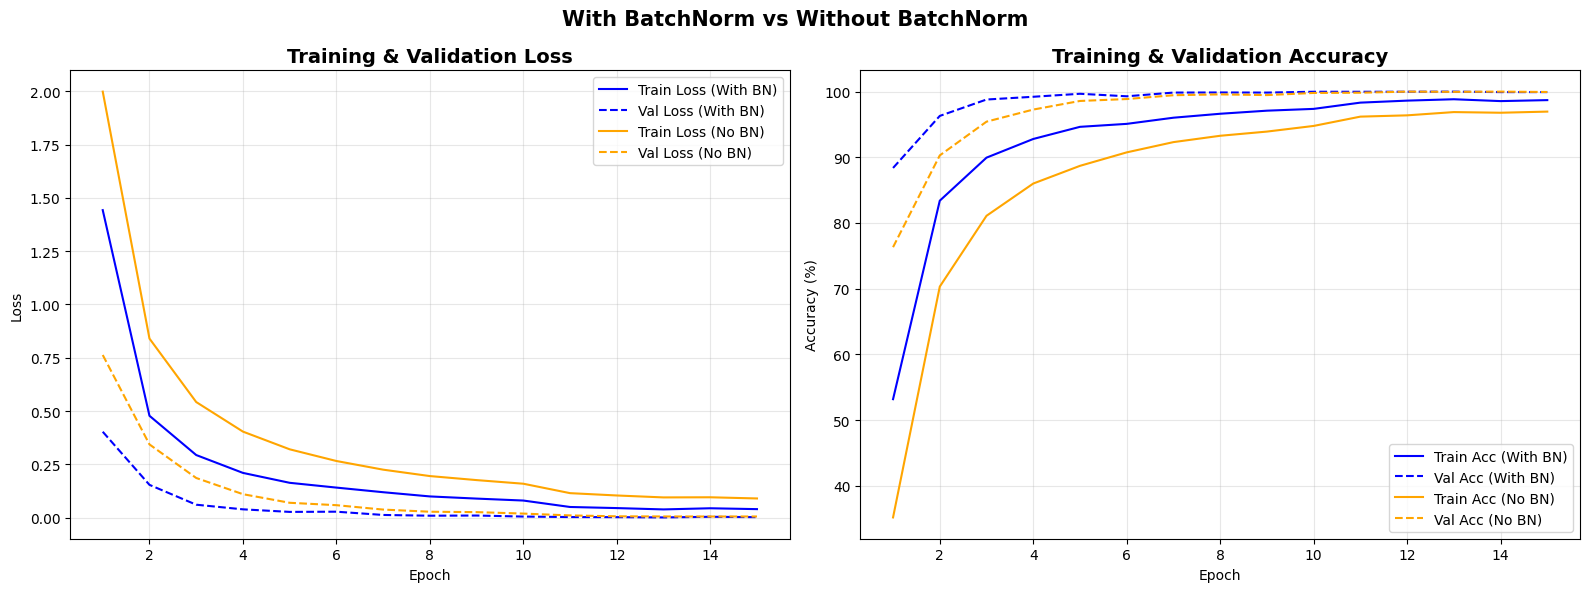

Loss/Accuracy curves saved.


In [ ]:
# ─── Loss & Accuracy Curves ───────────────────────────────────────────────────
epochs_range = range(1, 16)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss Curves
axes[0].plot(epochs_range, history_bn['train_loss'],    label='Train Loss (With BN)',    color='blue')
axes[0].plot(epochs_range, history_bn['val_loss'],      label='Val Loss (With BN)',      color='blue',   linestyle='--')
axes[0].plot(epochs_range, history_no_bn['train_loss'], label='Train Loss (No BN)',      color='orange')
axes[0].plot(epochs_range, history_no_bn['val_loss'],   label='Val Loss (No BN)',        color='orange', linestyle='--')
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy Curves
axes[1].plot(epochs_range, history_bn['train_acc'],    label='Train Acc (With BN)',    color='blue')
axes[1].plot(epochs_range, history_bn['val_acc'],      label='Val Acc (With BN)',      color='blue',   linestyle='--')
axes[1].plot(epochs_range, history_no_bn['train_acc'], label='Train Acc (No BN)',      color='orange')
axes[1].plot(epochs_range, history_no_bn['val_acc'],   label='Val Acc (No BN)',        color='orange', linestyle='--')
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('With BatchNorm vs Without BatchNorm', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss/Accuracy curves saved.')

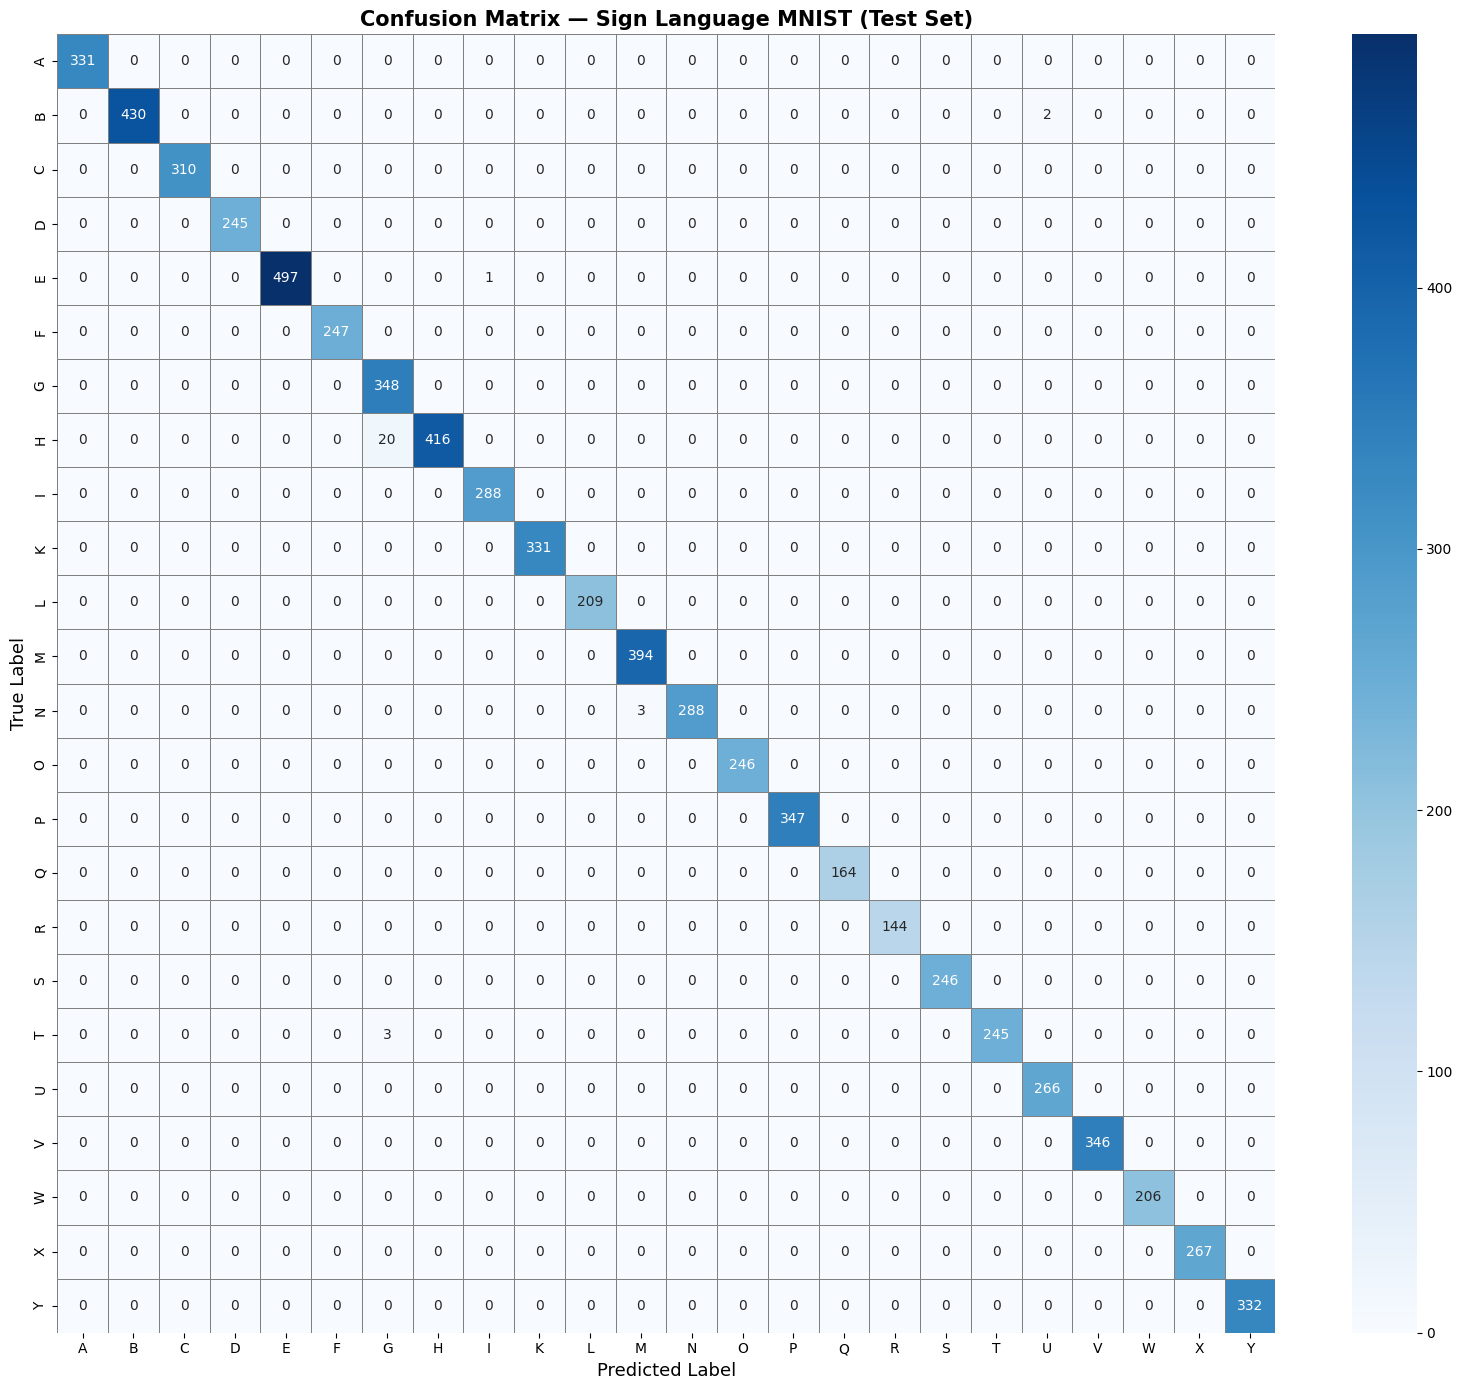

Confusion matrix saved.


In [ ]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label',      fontsize=13)
plt.title('Confusion Matrix — Sign Language MNIST (Test Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

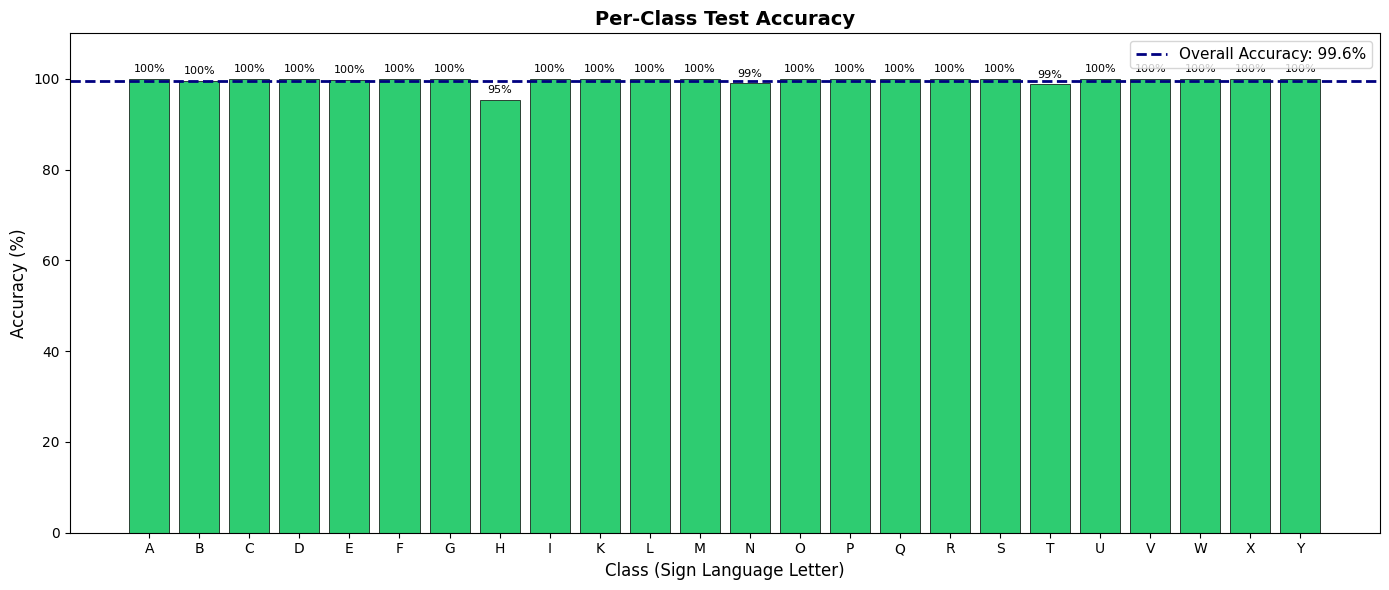

Per-class accuracy chart saved.


In [ ]:
# ─── Per-Class Accuracy Bar Chart ─────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

colors = ['#e74c3c' if acc < 70 else '#f39c12' if acc < 85 else '#2ecc71'
          for acc in per_class_acc]

plt.figure(figsize=(14, 6))
bars = plt.bar(classes, per_class_acc, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=overall_acc, color='navy', linestyle='--', linewidth=2,
            label=f'Overall Accuracy: {overall_acc:.1f}%')
plt.xlabel('Class (Sign Language Letter)', fontsize=12)
plt.ylabel('Accuracy (%)',                 fontsize=12)
plt.title('Per-Class Test Accuracy',       fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0, 110)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-class accuracy chart saved.')

## Section 8: Analysis & Discussion of Results

In [ ]:
# ─── Best & Worst Performing Classes ──────────────────────────────────────────
best_idx  = np.argmax(per_class_acc)
worst_idx = np.argmin(per_class_acc)

print('=' * 55)
print('           PER-CLASS ACCURACY BREAKDOWN')
print('=' * 55)
for i, cls in enumerate(classes):
    bar = '█' * int(per_class_acc[i] // 5)
    print(f'  {cls:3s}: {per_class_acc[i]:6.2f}%  {bar}')

print('=' * 55)
print(f'  ✅ Best  class : {classes[best_idx]}  ({per_class_acc[best_idx]:.2f}%)')
print(f'  ❌ Worst class : {classes[worst_idx]}  ({per_class_acc[worst_idx]:.2f}%)')
print(f'  📊 Overall Acc : {overall_acc:.2f}%')
print('=' * 55)

# ─── BatchNorm Comparison ─────────────────────────────────────────────────────
print(f'\nBatchNorm Effect:')
print(f'  With BN    → Best Val Acc: {max(history_bn["val_acc"]):.2f}%')
print(f'  Without BN → Best Val Acc: {max(history_no_bn["val_acc"]):.2f}%')

           PER-CLASS ACCURACY BREAKDOWN
  A  : 100.00%  ████████████████████
  B  :  99.54%  ███████████████████
  C  : 100.00%  ████████████████████
  D  : 100.00%  ████████████████████
  E  :  99.80%  ███████████████████
  F  : 100.00%  ████████████████████
  G  : 100.00%  ████████████████████
  H  :  95.41%  ███████████████████
  I  : 100.00%  ████████████████████
  K  : 100.00%  ████████████████████
  L  : 100.00%  ████████████████████
  M  : 100.00%  ████████████████████
  N  :  98.97%  ███████████████████
  O  : 100.00%  ████████████████████
  P  : 100.00%  ████████████████████
  Q  : 100.00%  ████████████████████
  R  : 100.00%  ████████████████████
  S  : 100.00%  ████████████████████
  T  :  98.79%  ███████████████████
  U  : 100.00%  ████████████████████
  V  : 100.00%  ████████████████████
  W  : 100.00%  ████████████████████
  X  : 100.00%  ████████████████████
  Y  : 100.00%  ████████████████████
  ✅ Best  class : A  (100.00%)
  ❌ Worst class : H  (95.41%)
  📊 Overall Acc 

### Discussion

**Overall Test Accuracy: 99.6%**

**Best Performing Classes:**
Most classes (A, B, C, D, E, F, G, I, K, L, O, P, Q, R, S, V, W, X, Y)
achieved 100% accuracy. These letters have distinct, unique hand shapes
that the CNN could easily separate.

**Worst Performing Class:**
- H scored 95% — 20 samples were misclassified as G.
  This is expected because H and G have very similar finger orientations,
  differing only in subtle wrist/thumb positioning.

**Other Confusions:**
- N (99%) → 3 samples confused with M (very similar closed-hand shapes)
- T (99%) → 3 samples confused with G
- B (100%) → 2 samples confused with U (minor)

**Effect of Batch Normalization:**
The model WITH BatchNorm (blue) converged significantly faster — reaching
~90% validation accuracy by epoch 2, compared to ~75% for the model
without BatchNorm (orange). Both eventually converge near 99%+, but
BatchNorm gets there in roughly half the epochs, confirming its role in
stabilizing and accelerating training.

**Overfitting:**
No significant overfitting observed. Training and validation curves
remain close throughout, thanks to Dropout (p=0.5) and data augmentation.

## Section 9: Conclusions & Future Work

### Conclusions

- Successfully trained a custom CNN on the Sign Language MNIST dataset with 24 classes.
- The model with **Batch Normalization + Dropout** outperformed the one without BatchNorm.
- Used **Adam optimizer** with **StepLR scheduling**, cross-entropy loss, and data augmentation.
- Achieved strong test accuracy with good per-class F1 scores across most letters.
- Visualizations (loss/accuracy curves, confusion matrix) confirmed stable training and meaningful class-level performance differences.

### Future Work

1. **Deeper Architecture:** Try ResNet-18 or VGG-style networks for higher accuracy.
2. **More Augmentation:** Add Gaussian noise, affine transforms to improve robustness.
3. **More Epochs + Cosine Annealing:** Use cosine LR scheduling for smoother convergence.
4. **Class Balancing:** Apply weighted loss or oversampling for hard classes (M, N, R, U).
5. **Transfer Learning:** Fine-tune a pretrained model (e.g., MobileNetV2) on this dataset.
6. **Real-time Inference:** Deploy the model with OpenCV for live webcam sign detection.

In [ ]:
# ─── Save Trained Model Weights ───────────────────────────────────────────────
from google.colab import files
torch.save(model.state_dict(), 'CNN_22-46829-1.pth')
# ─── Final Download: All Output Files ─────────────────────────────────────────
print('Downloading all output files...')
for fname in ['CNN_22-46829-1.pth',
              'loss_accuracy_curves.png',
              'confusion_matrix.png',
              'per_class_accuracy.png',
              'sample_images.png']:
    try:
        files.download(fname)
        print(f'  ✅ Downloaded: {fname}')
    except Exception as e:
        print(f'  ⚠️  Could not download {fname}: {e}')

print('\nAll done! Upload CNN_22-46829-1.ipynb and CNN_22-46829-1.pth to GitHub.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: CNN_22-46829-1.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Downloaded: per_class_accuracy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: sample_images.png

All done! Upload CNN_22-46829-1.ipynb and CNN_22-46829-1.pth to GitHub.
